Annual Expected Return: 0.08738280983820737
Annual Volatility: 0.19773244508573312
Value at Risk (95% confidence): -0.23335570781062634
count    1528.000000
mean        0.000347
std         0.012456
min        -0.113827
25%        -0.005557
50%         0.000222
75%         0.006610
max         0.091691
dtype: float64


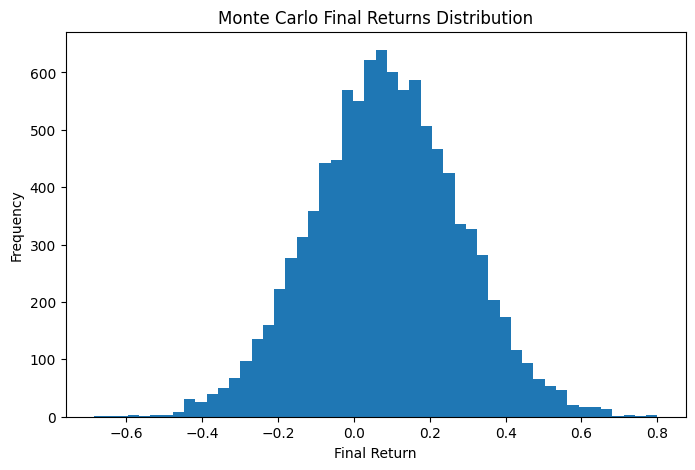

In [4]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

prices = pd.read_csv(
    "cleaned_prices_data.csv",
    index_col=0,
    parse_dates=True
)

log_returns = np.log(prices / prices.shift(1)).dropna()
log_returns.to_csv("log_returns.csv")

corr_matrix = log_returns.corr()
cov_matrix = log_returns.cov()

corr_matrix.to_csv("correlation_matrix.csv")
cov_matrix.to_csv("covariance_matrix.csv")

weights = np.ones(len(log_returns.columns)) / len(log_returns.columns)

portfolio_returns = log_returns.dot(weights)

portfolio_variance = np.dot(weights.T, np.dot(cov_matrix, weights))
portfolio_std = np.sqrt(portfolio_variance)

annual_return = portfolio_returns.mean() * 252
annual_volatility = portfolio_std * np.sqrt(252)

mean = portfolio_returns.mean()
std = portfolio_returns.std()

days = 252
num_simulations = 10000

simulated_returns = np.random.normal(
    mean,
    std,
    (days, num_simulations)
)

portfolio_paths = simulated_returns.cumsum(axis=0)
final_values = portfolio_paths[-1, :]

mc_df = pd.DataFrame(final_values, columns=["Final_Return"])
mc_df.to_csv("monte_carlo_results.csv", index=False)

VaR_95 = np.percentile(final_values, 5)

historical_vol = log_returns.std() * np.sqrt(252)
rolling_vol = log_returns.rolling(30).std() * np.sqrt(252)

historical_vol.to_csv("historical_volatility.csv")
rolling_vol.to_csv("rolling_volatility.csv")

print("Annual Expected Return:", annual_return)
print("Annual Volatility:", annual_volatility)
print("Value at Risk (95% confidence):", VaR_95)
print(portfolio_returns.describe())

plt.figure(figsize=(8,5))
plt.hist(final_values, bins=50)
plt.title("Monte Carlo Final Returns Distribution")
plt.xlabel("Final Return")
plt.ylabel("Frequency")
plt.show()

